# Data Exploration Notebook

This notebook explores the output of the data pipeline for the regime-portfolio project.

**Project:** Adaptive Portfolio Allocation with Market Regime Detection (E448)

**Purpose:** Validate the feature matrix and explore key characteristics before regime detection.

In [1]:
import sys
from pathlib import Path

# Add src to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

## 1. Load Feature Data

In [2]:
# Load the features
features_path = PROJECT_ROOT / "data" / "processed" / "features.parquet"

if features_path.exists():
    features = pd.read_parquet(features_path)
    print(f"Loaded features: {features.shape}")
    print(f"Date range: {features.index.min().date()} to {features.index.max().date()}")
else:
    print(f"Features not found at {features_path}")
    print("Run: python scripts/build_dataset.py --config config/data.yaml")

Loaded features: (4798, 39)
Date range: 2007-05-31 to 2026-06-25


In [3]:
# Display columns by type
if 'features' in dir():
    return_cols = [c for c in features.columns if c.endswith('_ret')]
    vol_cols = [c for c in features.columns if '_vol' in c]
    corr_cols = [c for c in features.columns if '_corr' in c]
    dd_cols = [c for c in features.columns if c.endswith('_dd')]
    macro_cols = [c for c in features.columns if c in ['VIXCLS', 'T10Y2Y', 'BAA10Y', 'NFCI']]
    
    print(f"Return features: {len(return_cols)}")
    print(f"Volatility features: {len(vol_cols)}")
    print(f"Correlation features: {len(corr_cols)}")
    print(f"Drawdown features: {len(dd_cols)}")
    print(f"Macro features: {len(macro_cols)}")

Return features: 6
Volatility features: 12
Correlation features: 11
Drawdown features: 6
Macro features: 4


## 2. Summary Statistics

In [4]:
if 'features' in dir():
    print("Return Statistics (annualised):")
    returns = features[return_cols]
    stats = pd.DataFrame({
        'Mean (ann)': returns.mean() * 252,
        'Std (ann)': returns.std() * np.sqrt(252),
        'Sharpe': (returns.mean() * 252) / (returns.std() * np.sqrt(252)),
        'Min': returns.min(),
        'Max': returns.max(),
    })
    display(stats.round(4))

Return Statistics (annualised):


,Mean (ann),Std (ann),Sharpe,Min,Max
SPY_ret,0.1008,0.1979,0.5092,-0.1159,0.1356
TLT_ret,0.0315,0.1520,0.2072,-0.0690,0.0725
LQD_ret,0.0410,0.0888,0.4618,-0.0955,0.0932
GLD_ret,0.0915,0.1816,0.5039,-0.1084,0.1070
DBC_ret,0.0142,0.1934,0.0737,-0.0828,0.0665
BIL_ret,0.0135,0.0049,2.7661,-0.0039,0.0043


## 3. Correlation Analysis

The core premise: diversifying correlations rise during crises.

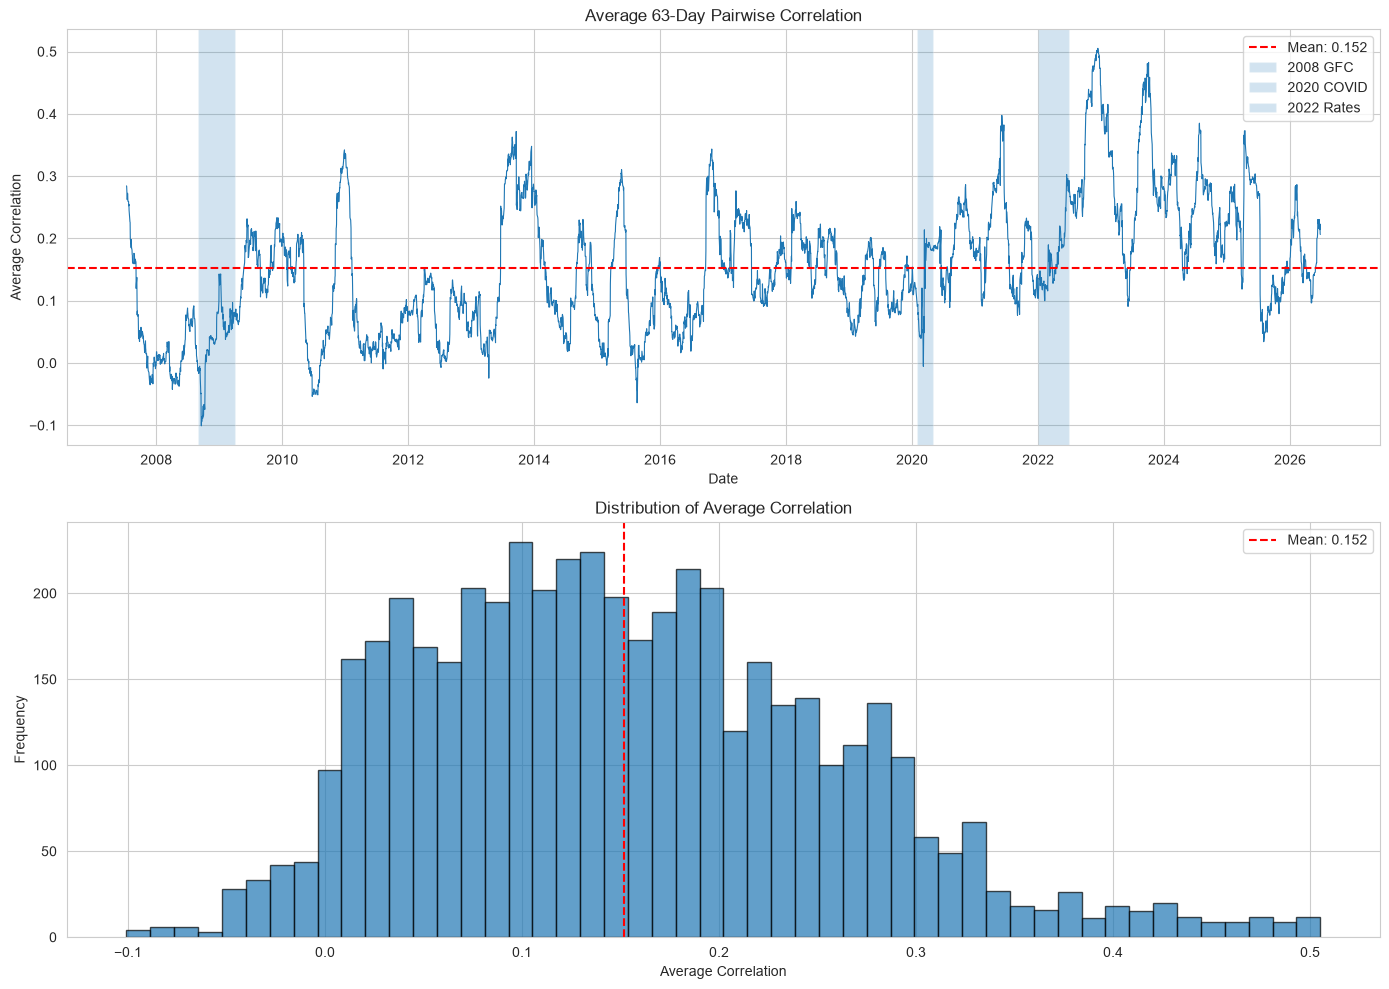

In [5]:
if 'features' in dir() and 'avg_corr63d' in features.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Average correlation over time
    ax = axes[0]
    avg_corr = features['avg_corr63d'].dropna()
    ax.plot(avg_corr.index, avg_corr.values, linewidth=0.8)
    ax.axhline(y=avg_corr.mean(), color='red', linestyle='--', label=f'Mean: {avg_corr.mean():.3f}')
    
    # Highlight crisis periods
    crisis_periods = [
        ("2008-09-01", "2009-03-31", "2008 GFC"),
        ("2020-02-01", "2020-04-30", "2020 COVID"),
        ("2022-01-01", "2022-06-30", "2022 Rates"),
    ]
    for start, end, label in crisis_periods:
        try:
            ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.2, label=label)
        except:
            pass
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Average Correlation')
    ax.set_title('Average 63-Day Pairwise Correlation')
    ax.legend()
    
    # Distribution
    ax = axes[1]
    ax.hist(avg_corr, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(x=avg_corr.mean(), color='red', linestyle='--', label=f'Mean: {avg_corr.mean():.3f}')
    ax.set_xlabel('Average Correlation')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Average Correlation')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

## 4. Volatility Regimes

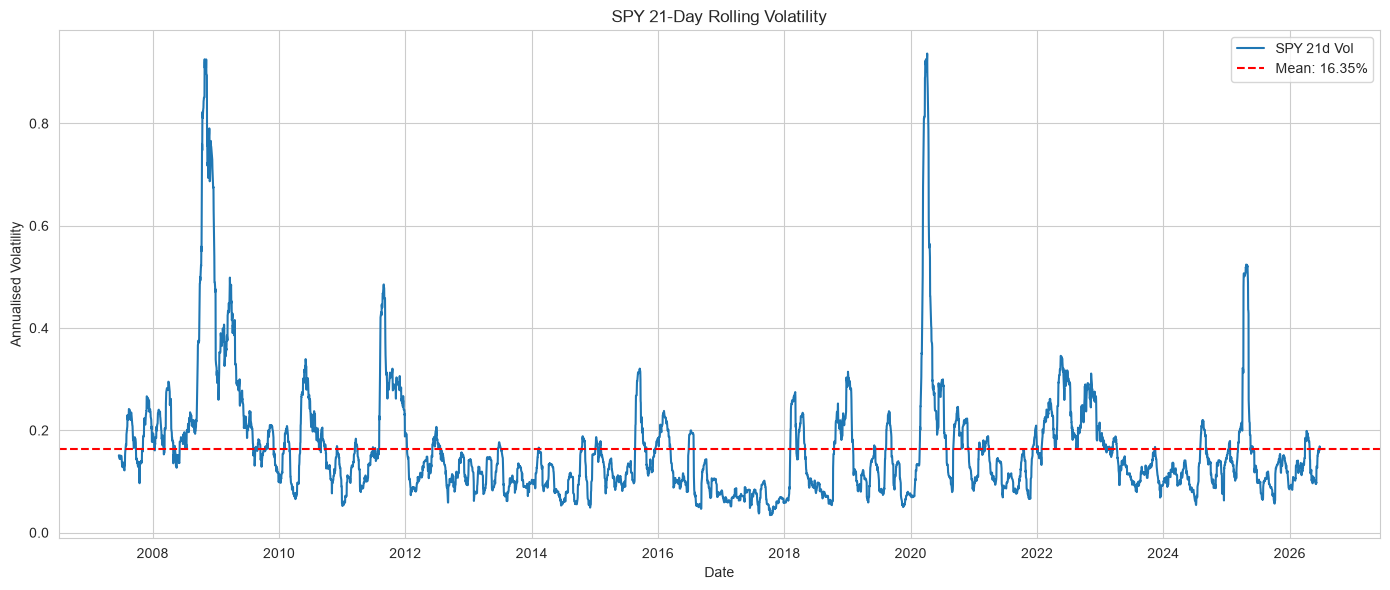

In [6]:
if 'features' in dir():
    fig, ax = plt.subplots(figsize=(14, 6))
    
    spy_vol = features.get('SPY_vol21d')
    if spy_vol is not None:
        ax.plot(spy_vol.dropna().index, spy_vol.dropna().values, label='SPY 21d Vol')
        ax.axhline(y=spy_vol.mean(), color='red', linestyle='--', label=f'Mean: {spy_vol.mean():.2%}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Annualised Volatility')
        ax.set_title('SPY 21-Day Rolling Volatility')
        ax.legend()
    
    plt.tight_layout()
    plt.show()

## 5. Drawdown Analysis

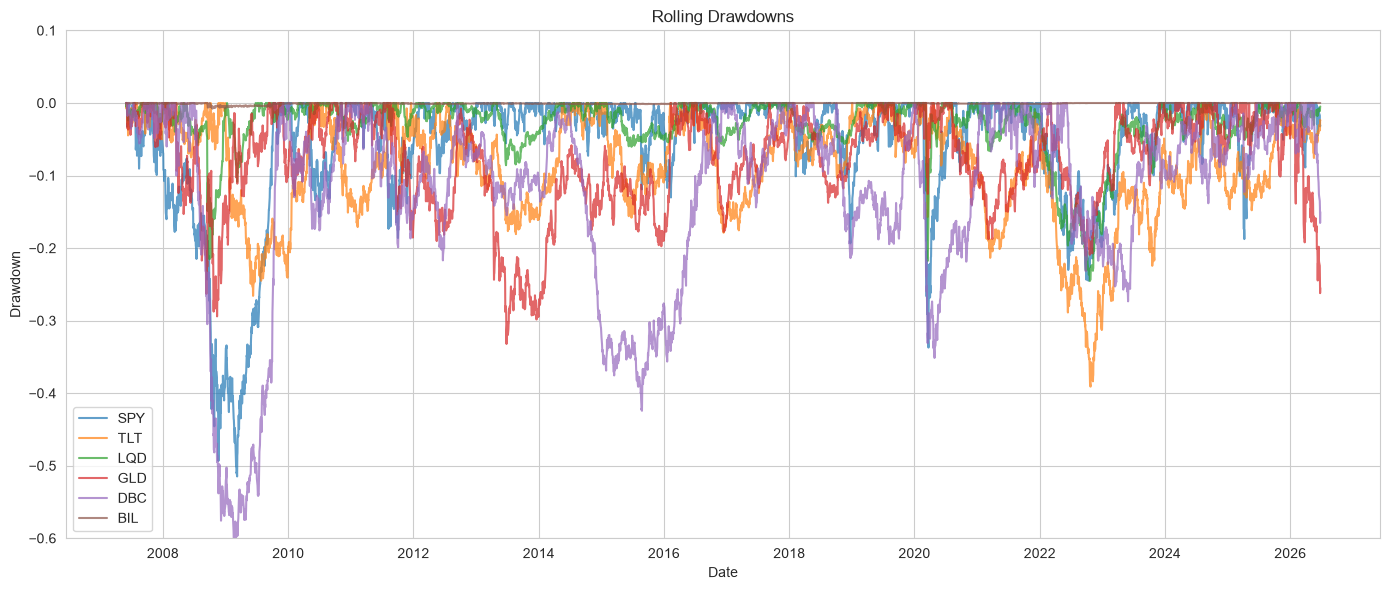

In [7]:
if 'features' in dir():
    fig, ax = plt.subplots(figsize=(14, 6))
    
    for col in dd_cols:
        dd = features[col].dropna()
        ax.plot(dd.index, dd.values, label=col.replace('_dd', ''), alpha=0.7)
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Drawdown')
    ax.set_title('Rolling Drawdowns')
    ax.legend()
    ax.set_ylim(-0.6, 0.1)
    
    plt.tight_layout()
    plt.show()

## 6. Macro Features

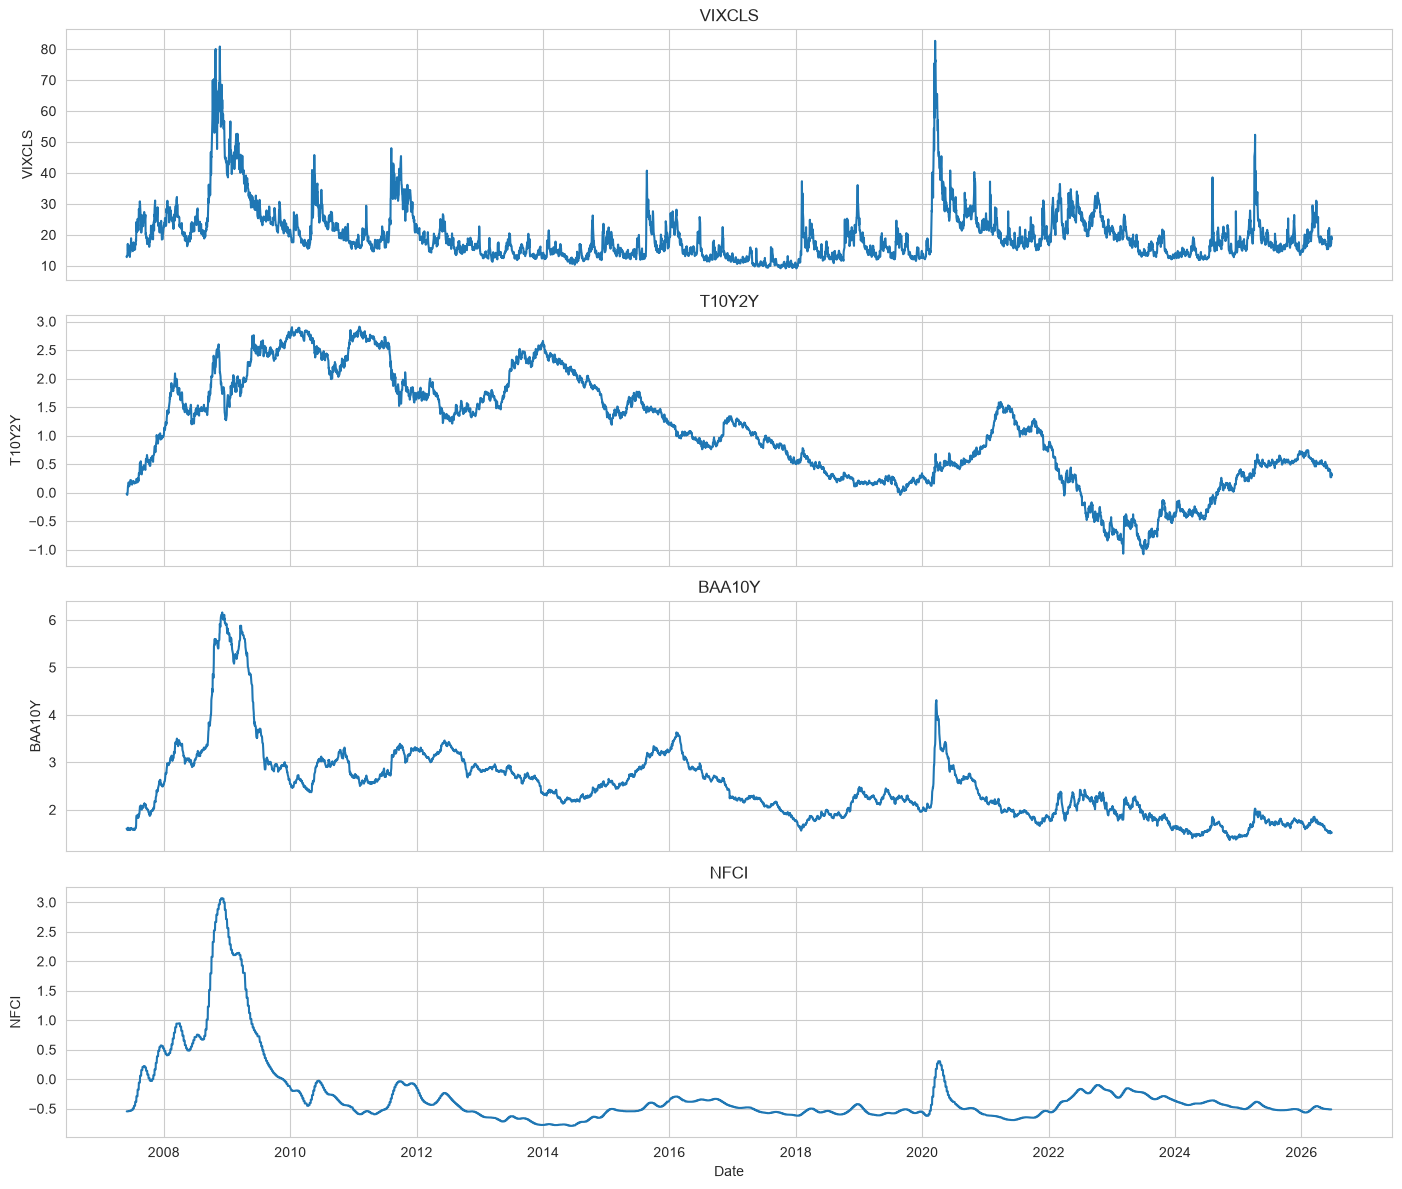

In [8]:
if 'features' in dir() and macro_cols:
    fig, axes = plt.subplots(len(macro_cols), 1, figsize=(14, 3*len(macro_cols)), sharex=True)
    
    if len(macro_cols) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, macro_cols):
        data = features[col].dropna()
        ax.plot(data.index, data.values)
        ax.set_ylabel(col)
        ax.set_title(col)
    
    plt.xlabel('Date')
    plt.tight_layout()
    plt.show()

## 7. Missingness Check

In [9]:
if 'features' in dir():
    missing = features.isna().sum().sort_values(ascending=False)
    missing_pct = (missing / len(features) * 100).round(2)
    
    print("Columns with missing values:")
    display(missing_pct[missing_pct > 0].to_frame('Missing %'))

Columns with missing values:


,Missing %
NFCI,2.21
LQD_GLD_corr63d,0.60
TLT_GLD_corr63d,0.60
SPY_GLD_corr63d,0.60
SPY_DBC_corr63d,0.60
SPY_LQD_corr63d,0.60
SPY_TLT_corr63d,0.60
TLT_DBC_corr63d,0.60
LQD_DBC_corr63d,0.60
avg_corr63d,0.60


## 8. Feature Correlations

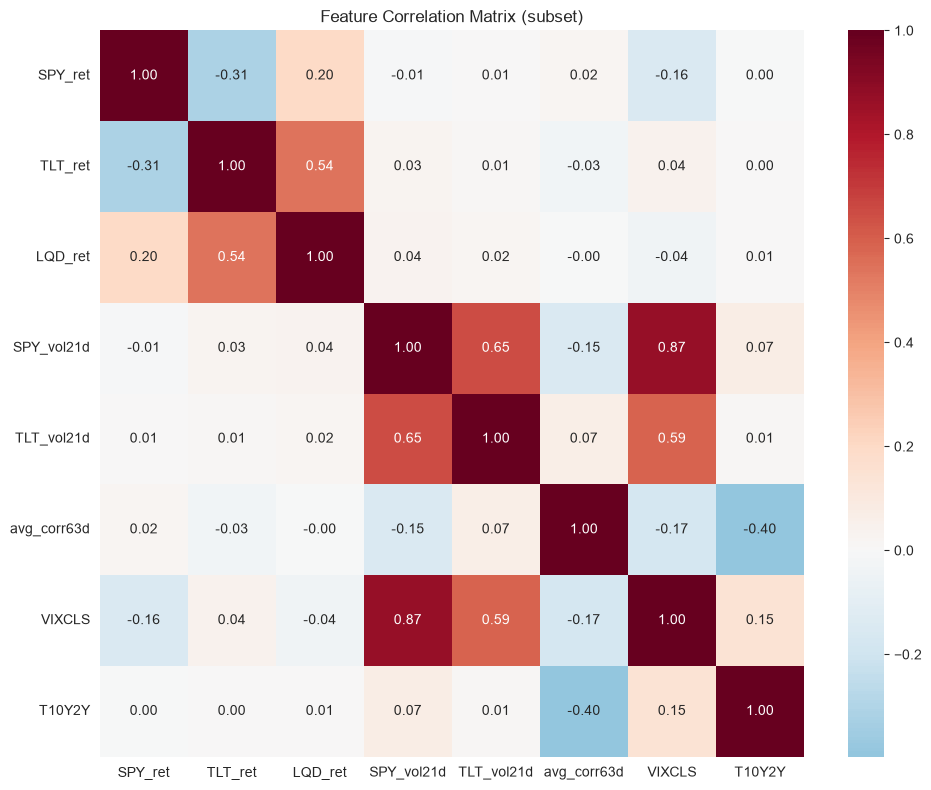

In [10]:
if 'features' in dir():
    # Select a subset for visualization
    subset_cols = return_cols[:3] + vol_cols[:2] + ['avg_corr63d'] + macro_cols[:2]
    subset_cols = [c for c in subset_cols if c in features.columns]
    
    corr_matrix = features[subset_cols].dropna().corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
    ax.set_title('Feature Correlation Matrix (subset)')
    plt.tight_layout()
    plt.show()

## 9. Sanity Check: Correlation Spikes During Crises

This validates the core premise of the thesis.

In [11]:
if 'features' in dir() and 'avg_corr63d' in features.columns:
    avg_corr = features['avg_corr63d']
    
    # Define crisis periods
    crises = {
        '2008 GFC': ('2008-09-01', '2009-03-31'),
        '2020 COVID': ('2020-02-01', '2020-04-30'),
        '2022 Rate Hikes': ('2022-01-01', '2022-06-30'),
    }
    
    print("Average Correlation During Crisis Periods vs. Full Sample:")
    print(f"Full sample mean: {avg_corr.mean():.4f}")
    print()
    
    for name, (start, end) in crises.items():
        try:
            crisis_corr = avg_corr.loc[start:end]
            if len(crisis_corr) > 0:
                print(f"{name}:")
                print(f"  Mean: {crisis_corr.mean():.4f}")
                print(f"  Max:  {crisis_corr.max():.4f}")
                print(f"  Ratio to full sample: {crisis_corr.mean() / avg_corr.mean():.2f}x")
                print()
        except:
            print(f"{name}: Not in data range")

Average Correlation During Crisis Periods vs. Full Sample:
Full sample mean: 0.1519

2008 GFC:
  Mean: 0.0352
  Max:  0.1430
  Ratio to full sample: 0.23x

2020 COVID:
  Mean: 0.1283
  Max:  0.2139
  Ratio to full sample: 0.84x

2022 Rate Hikes:
  Mean: 0.1717
  Max:  0.3027
  Ratio to full sample: 1.13x

